<a href="https://www.kaggle.com/code/onosebraimah/diabetes-pca?scriptVersionId=350378155" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mragpavank/diabetes/diabetes.csv


# DIABETES PCA

This notebook applies Principal Component Analysis (PCA) to the Pima Indians Diabetes dataset. The goal is to reduce the 8 features into fewer dimensions, visualise the data, and explore whether PCA can help separate diabetic from non-diabetic patients.

In [2]:
df = pd.read_csv('/kaggle/input/datasets/mragpavank/diabetes/diabetes.csv')

Loading the dataset and doing an initial inspection to understand its structure. How many rows, what columns we have, and what the data looks like.

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.shape

(768, 9)

In [6]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [7]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Checking for zeros across key medical columns. A blood pressure, BMI, glucose or insulin reading of zero is not medically possible. These are likely missing values recorded as zeros and need to be handled before applying PCA.

In [8]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [9]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

Replacing all zeros with nan so pandas can recognise them as missing values. This affects Glucose, BloodPressure, SkinThickness, Insulin and BMI.

In [10]:
df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] = df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']].replace(0,np.nan)

Filling missing BMI and Glucose values using the mean BMI and Glucose of people the same age. This is more accurate than using the overall mean since BMI tends to vary with age. Glucose is also filled the same way since glucose levels can vary with age.

In [11]:
def fill_mean(series):
    return series.fillna(series.mean())

df['BMI'] = df.groupby('Age')['BMI'].transform(fill_mean)
df['Glucose'] = df.groupby('Age')['Glucose'].transform(fill_mean)

Filling missing Insulin values using the median of people with the same Glucose reading. Insulin and glucose are closely related, higher glucose usually means higher insulin. Median is used instead of mean because insulin has extreme values that would skew the mean.

In [12]:
def fill_median(series):
    return series.fillna(series.median())

df['Insulin'] = df.groupby('Glucose')['Insulin'].transform(fill_median)

For the missing values in BloodPressure, Insulin and SkinThickness, filling with the overall median.

In [13]:
df['BloodPressure'] = df['BloodPressure'].fillna(df['BloodPressure'].median())
df['SkinThickness'] = df['SkinThickness'].fillna(df['SkinThickness'].median())
df['Insulin'] = df['Insulin'].fillna(df['Insulin'].median())

In [14]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Separating the features from the target label. X contains all 8 measurement columns. The Outcome column (0 = no diabetes, 1 = diabetes) is set aside. PCA does not use labels.

In [15]:
X = df.drop(columns=['Outcome'])

In [16]:
X.shape

(768, 8)

In [17]:
X.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Standardising the features so every column has a mean of 0 and standard deviation of 1. This is essential before PCA because features on larger scales would otherwise dominate the principal components.

In [18]:
X_scaled = StandardScaler().fit_transform(X)

In [19]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

In [20]:
X_scaled_df.mean()

Pregnancies                -6.476301e-17
Glucose                    -2.405483e-16
BloodPressure               5.782412e-18
SkinThickness              -1.526557e-16
Insulin                    -8.789266e-17
BMI                         2.659909e-16
DiabetesPedigreeFunction    2.451743e-16
Age                         1.931325e-16
dtype: float64

In [21]:
X_scaled_df.std()

Pregnancies                 1.000652
Glucose                     1.000652
BloodPressure               1.000652
SkinThickness               1.000652
Insulin                     1.000652
BMI                         1.000652
DiabetesPedigreeFunction    1.000652
Age                         1.000652
dtype: float64

In [22]:
pca = PCA()

Fitting a full PCA with no component limit to see how variance is spread across all 8 components. This helps us decide how many components to keep.

In [23]:
X_pca = pca.fit_transform(X_scaled_df)

In [24]:
ev = pca.explained_variance_ratio_

In [25]:
ev

array([0.29977411, 0.18516966, 0.14376644, 0.11701028, 0.09500436,
       0.05951913, 0.05229059, 0.04746543])

In [26]:
perc_ev = ev * 100
perc_ev2 = perc_ev.round(2)
perc_ev2

array([29.98, 18.52, 14.38, 11.7 ,  9.5 ,  5.95,  5.23,  4.75])

Plotting the explained variance per component as a bar chart. The tallest bar is PC1 and it always captures the most variance. The elbow point is where the bars start to flatten, indicating diminishing returns from adding more components.

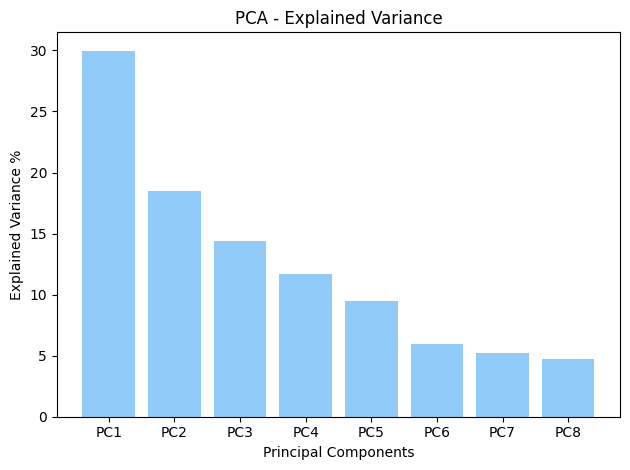

In [27]:
plt.figure()
plt.bar(range(pca.n_components_), perc_ev2, alpha=0.5, align='center', color='#2196F3')
plt.title('PCA - Explained Variance')
plt.ylabel('Explained Variance %')
plt.xlabel('Principal Components')
plt.xticks(range(pca.n_components_), [f'PC{i+1}' for i in range(pca.n_components_)])
plt.tight_layout()
plt.show()

Calculating the cumulative variance. This shows how much total information is retained as we add more components one by one.

In [28]:
cumvar = np.cumsum(perc_ev)
cumvar

array([ 29.97741064,  48.49437691,  62.87102083,  74.5720487 ,
        84.07248464,  90.02439754,  95.25345656, 100.        ])

Plotting the cumulative variance curve with a 90% threshold line. Where the curve crosses the dashed line tells us the minimum number of components needed to retain 90% of the data's information.

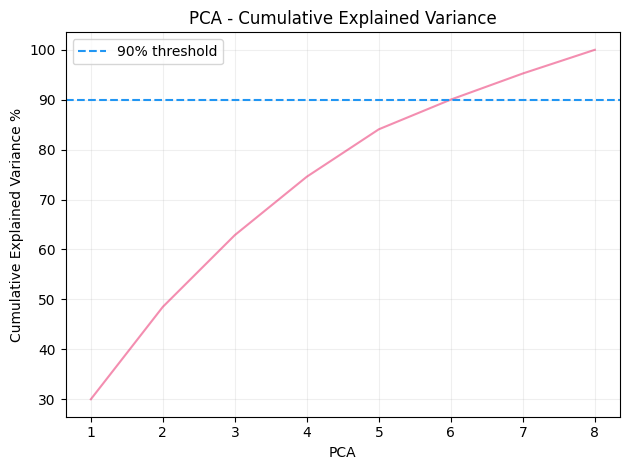

In [29]:
plt.figure()
plt.plot(range(1, pca.n_components_+1), cumvar, alpha=0.5,  color='#E91E63')
plt.title('PCA - Cumulative Explained Variance')
plt.ylabel('Cumulative Explained Variance %')
plt.xlabel('PCA')
plt.axhline(y=90, color='#2196F3', linestyle='--', label='90% threshold')
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [30]:
num_components = np.argmax(cumvar >= 90) + 1
print(f'Min components for 90% variance: {num_components:}')

Min components for 90% variance: 6


Now reducing to just 2 components specifically for visualisation. While more components may be needed for modelling, 2 components allow us to plot the data and visually inspect whether the groups are separable.

In [31]:
pca_2 = PCA(n_components=2)

In [32]:
y = df['Outcome']

In [33]:
X_pca = pca_2.fit_transform(X_scaled_df)
X_pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
X_pca_df['Outcome'] = y.values

In [34]:
print(X_pca_df.shape)
print(f"Total variance retained: {pca_2.explained_variance_ratio_.sum():.2%}")

(768, 3)
Total variance retained: 48.49%


Plotting PC1 vs PC2 coloured by diabetes outcome. Green points represent non-diabetic patients, red points represent diabetic patients. If the groups cluster separately, it suggests PCA has captured meaningful structure in the data.

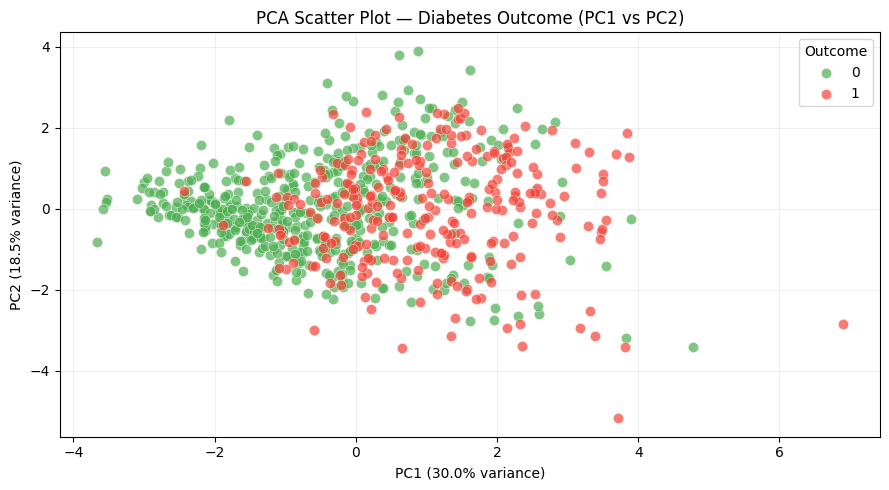

In [35]:
colors = {0: '#4CAF50', 1: '#F44336'}

plt.figure(figsize=(9, 5))

for label, group in X_pca_df.groupby('Outcome'):
    plt.scatter(
        group['PC1'], group['PC2'],
        label=label,
        color=colors[label],
        alpha=0.7, s=55, edgecolors='white', linewidths=0.4
    )

plt.xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA Scatter Plot — Diabetes Outcome (PC1 vs PC2)")
plt.legend(title='Outcome')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

**Conclusion:** This notebook applied PCA to the Pima Indians Diabetes dataset to explore whether 8 medical measurements can separate diabetic from non-diabetic patients.
After cleaning zero values and standardising the features, PCA was applied. The scatter plot shows the two groups overlap significantly, meaning the differences between diabetic and non-diabetic patients are subtle and spread across multiple features.
PCA is still useful as a pre-processing step since it reduces noise and removes correlated features. However, a classification model will need more than 2 components to distinguish patients accurately.